# 03 — Fine-Tuning DistilBERT (Transformer Model)
**SEA 820 Final Project: Detecting AI-Generated Text**

Team: Aditi & Victoria

This notebook fine-tunes **`distilbert-base-uncased`** with the Hugging Face
`Trainer` API to classify text as human (0) or AI (1), then compares it against
the TF-IDF baseline from `02_baseline_tfidf.ipynb`.

**Runtime:** use a **GPU** (Colab → *Runtime → Change runtime type → T4 GPU*).
We reproduce the *exact* stratified split from notebook `02` so the comparison is
apples-to-apples.

**What we do:**
1. Reproduce the filtered, stratified split (identical seed).
2. Tokenize with the DistilBERT tokenizer.
3. Fine-tune with `Trainer`, logging **two hyperparameter configurations**.
4. Evaluate on the held-out test set (accuracy, precision, recall, F1).
5. Compare directly against the baseline.

## 0. Setup

In [1]:
# Colab usually has these; install/upgrade to be safe.
!pip install -q -U transformers datasets accelerate

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import Dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, DataCollatorWithPadding,
                          set_seed)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)

RANDOM_STATE = 42
set_seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type != "cuda":
    print("WARNING: no GPU detected. Fine-tuning on CPU is very slow — "
          "switch to a GPU runtime.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 11.7 MB/s eta 0:00:00
Using device: cuda


## Resources

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# Change to your project directory on Google Drive
# Replace 'Your_Project_Directory' with the actual path to your project folder.
# For example: '/content/drive/MyDrive/SEA_820_Final_Project'
project_path = '/content/drive/MyDrive'
%cd {project_path}

Mounted at /content/drive
/content/drive/MyDrive


In [3]:
import pandas as pd

# Load the AI_Human (1).csv file from the specified path
df_mounted = pd.read_csv('AI_Human (1).csv')

# Display the first 5 rows to verify the data is loaded correctly
display(df_mounted.head())

,text,generated
0,Cars. Cars have been around since they became ...,0.0
1,Transportation is a large necessity in most co...,0.0
2,"""America's love affair with it's vehicles seem...",0.0
3,How often do you ride in a car? Do you drive a...,0.0
4,Cars are a wonderful thing. They are perhaps o...,0.0


The `AI_Human (1).csv` has been loaded from your Google Drive. You can now use `df_mounted` for further analysis.

## 2. Reproduce the baseline split
Identical filters and seed as notebook `02` → the **test set is the same 20%**,
so the two models are evaluated on exactly the same examples.

**Compute note:** full fine-tuning on ~390k training rows takes hours on a free
T4. We train on a **stratified subsample** of the training set (configurable via
`N_TRAIN_SUBSAMPLE`) but **evaluate on the full test set**. Transformers are
sample-efficient, so this still gives a fair, strong comparison. Set
`N_TRAIN_SUBSAMPLE = None` to use all training data if you have the time/quota.

In [4]:
# --- config knobs ---
N_TRAIN_SUBSAMPLE = 40000   # rows used for fine-tuning; None = use all
MAX_LENGTH = 256            # EDA showed ~half of texts exceed 512 tokens; 256 keeps
                            # training fast while retaining most of the signal.

df = pd.read_csv("AI_Human.csv", usecols=["text", "generated"])
df["generated"] = df["generated"].astype("int8")

# Same EDA filters as notebook 02
df = df.drop_duplicates(subset="text")
df = df[(df["text"].str.count(r"\s+") + 1) >= 20].reset_index(drop=True)

# Rename to the column names HF expects
df = df.rename(columns={"generated": "label"})

train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=RANDOM_STATE, stratify=df["label"])

if N_TRAIN_SUBSAMPLE is not None:
    train_df = (train_df.groupby("label", group_keys=False)
                        .apply(lambda g: g.sample(
                            n=int(N_TRAIN_SUBSAMPLE * len(g) / len(train_df)),
                            random_state=RANDOM_STATE)))

print(f"Fine-tuning on {len(train_df):,} rows | evaluating on {len(test_df):,} rows")
print("Train balance:", train_df["label"].value_counts(normalize=True).round(3).to_dict())


Fine-tuning on 39,999 rows | evaluating on 97,440 rows
Train balance: {0: 0.628, 1: 0.372}


/tmp/ipykernel_673/1282977692.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(


## 3. Tokenize
Convert to Hugging Face `Dataset`s and tokenize with the DistilBERT tokenizer (dynamic padding via a data collator for efficiency).

In [5]:
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_ds = Dataset.from_pandas(train_df[["text", "label"]], preserve_index=False)
test_ds  = Dataset.from_pandas(test_df[["text", "label"]],  preserve_index=False)

def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)

train_tok = train_ds.map(tokenize_fn, batched=True, remove_columns=["text"])
test_tok  = test_ds.map(tokenize_fn,  batched=True, remove_columns=["text"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print(train_tok)


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/39999 [00:00<?, ? examples/s]

Map:   0%|          | 0/97440 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 39999
})


## 4. Metrics
`compute_metrics` returns everything the rubric asks for so it prints after every evaluation.

In [6]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy":       accuracy_score(labels, preds),
        "precision_ai":   precision_score(labels, preds, pos_label=1, zero_division=0),
        "recall_ai":      recall_score(labels, preds, pos_label=1, zero_division=0),
        "f1_ai":          f1_score(labels, preds, pos_label=1, zero_division=0),
        "f1_macro":       f1_score(labels, preds, average="macro"),
    }


## 5. Fine-tuning + hyperparameter experiments
We run **two configurations** and log both. A helper builds a fresh model and
`Trainer` for each run so experiments don't contaminate each other.

| Exp | Learning rate | Epochs | Batch |
|-----|---------------|--------|-------|
| A   | 2e-5          | 2      | 16    |
| B   | 5e-5          | 1      | 16    |

Extend this table with more runs (batch size, weight decay, `max_length`) and
keep the results — that systematic tuning is what earns the top rubric band.

In [7]:
experiment_log = []

def run_experiment(name, learning_rate, epochs, batch_size=16):
    """Fine-tune a fresh DistilBERT and return (trainer, eval_metrics)."""
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=2).to(device)

    args = TrainingArguments(
        output_dir=f"./distilbert_{name}",
        num_train_epochs=epochs,
        learning_rate=learning_rate,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=64,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="no",
        logging_steps=100,
        fp16=(device.type == "cuda"),   # mixed precision on GPU
        report_to="none",
        seed=RANDOM_STATE,
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_tok,
        eval_dataset=test_tok,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

    trainer.train()
    metrics = trainer.evaluate()
    metrics = {k.replace("eval_", ""): v for k, v in metrics.items()}
    experiment_log.append({
        "experiment": name, "lr": learning_rate, "epochs": epochs,
        "batch": batch_size,
        "accuracy": round(metrics["accuracy"], 4),
        "f1_ai": round(metrics["f1_ai"], 4),
        "f1_macro": round(metrics["f1_macro"], 4),
    })
    return trainer, metrics

In [8]:
# Experiment A
trainer_A, metrics_A = run_experiment("expA", learning_rate=2e-5, epochs=2)
print("Exp A:", {k: round(v, 4) for k, v in metrics_A.items() if isinstance(v, float)})


model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision Ai,Recall Ai,F1 Ai,F1 Macro
1,0.011161,0.022263,0.995351,0.993363,0.994157,0.993760,0.995028
2,0.018507,0.034025,0.993319,0.985714,0.996500,0.991077,0.992869


Training Loss,Validation Loss,Epoch,Accuracy,Precision Ai,Recall Ai,F1 Ai,F1 Macro
0.018507,0.034025,2,0.993319,0.985714,0.996500,0.991077,0.992869


Exp A: {'loss': 0.034, 'accuracy': 0.9933, 'precision_ai': 0.9857, 'recall_ai': 0.9965, 'f1_ai': 0.9911, 'f1_macro': 0.9929}


In [9]:
# Experiment B — different learning rate / epochs
trainer_B, metrics_B = run_experiment("expB", learning_rate=5e-5, epochs=1)
print("Exp B:", {k: round(v, 4) for k, v in metrics_B.items() if isinstance(v, float)})


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision Ai,Recall Ai,F1 Ai,F1 Macro
1,0.005349,0.022333,0.994684,0.989971,0.995810,0.992882,0.994320


Training Loss,Validation Loss,Epoch,Accuracy,Precision Ai,Recall Ai,F1 Ai,F1 Macro
0.005349,0.022333,1,0.994684,0.989971,0.995810,0.992882,0.994320


Exp B: {'loss': 0.0223, 'accuracy': 0.9947, 'precision_ai': 0.99, 'recall_ai': 0.9958, 'f1_ai': 0.9929, 'f1_macro': 0.9943}


### Experiment log

In [10]:
exp_df = pd.DataFrame(experiment_log)
print("Hyperparameter experiment log:")
exp_df


Hyperparameter experiment log:


,experiment,lr,epochs,batch,accuracy,f1_ai,f1_macro
0,expA,0.00002,2,16,0.9933,0.9911,0.9929
1,expB,0.00005,1,16,0.9947,0.9929,0.9943


## 6. Full evaluation of the best run
Pick the best experiment by macro-F1 and produce the full classification report + confusion matrix on the test set.

Best run: expB

              precision    recall  f1-score   support

       Human     0.9975    0.9940    0.9958     61159
          AI     0.9900    0.9958    0.9929     36281

    accuracy                         0.9947     97440
   macro avg     0.9937    0.9949    0.9943     97440
weighted avg     0.9947    0.9947    0.9947     97440



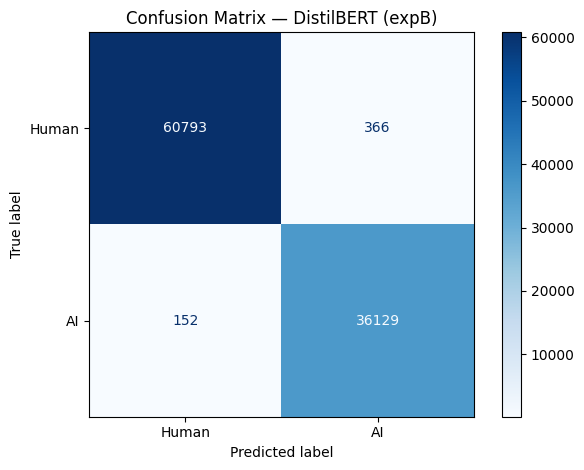

In [11]:
best_trainer = trainer_A if metrics_A["f1_macro"] >= metrics_B["f1_macro"] else trainer_B
best_name = "expA" if best_trainer is trainer_A else "expB"

pred_out = best_trainer.predict(test_tok)
y_pred = np.argmax(pred_out.predictions, axis=-1)
y_true = np.array(test_df["label"])

print(f"Best run: {best_name}\n")
print(classification_report(y_true, y_pred, target_names=["Human", "AI"], digits=4))

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Human", "AI"]).plot(cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix — DistilBERT ({best_name})")
plt.tight_layout(); plt.savefig("distilbert_confusion_matrix.png", dpi=150); plt.show()


## 7. Compare against the baseline
Loads `baseline_results.json` from notebook `02` (upload it or re-run `02` first) and builds the head-to-head table for the report.

In [12]:
import json

transformer_scores = {
    "Accuracy":     accuracy_score(y_true, y_pred),
    "Precision (AI)": precision_score(y_true, y_pred, pos_label=1),
    "Recall (AI)":  recall_score(y_true, y_pred, pos_label=1),
    "F1 (AI)":      f1_score(y_true, y_pred, pos_label=1),
    "F1 (macro)":   f1_score(y_true, y_pred, average="macro"),
}

rows = {"DistilBERT (fine-tuned)": {k: round(v, 4) for k, v in transformer_scores.items()}}

try:
    # CHANGED: read from Drive, matching where 02 now saves it
    with open("/content/drive/MyDrive/baseline_results.json") as f:
        base = json.load(f)
    bname = base["best_model"]
    bm = base["metrics"][bname]
    rows[f"Baseline — {bname}"] = {
        "Accuracy": bm["Accuracy"], "Precision (AI)": bm["Precision (AI)"],
        "Recall (AI)": bm["Recall (AI)"], "F1 (AI)": bm["F1 (AI)"],
        "F1 (macro)": bm["F1 (macro)"],
    }
except FileNotFoundError:
    print("baseline_results.json not found on Drive — run notebook 02 first "
          "(with Drive mounted) to generate it.")

comparison = pd.DataFrame(rows).T
print("Baseline vs. Transformer:")
comparison

Baseline vs. Transformer:


,Accuracy,Precision (AI),Recall (AI),F1 (AI),F1 (macro)
DistilBERT (fine-tuned),0.9947,0.9900,0.9958,0.9929,0.9943
Baseline — Linear SVM,0.9997,0.9995,0.9996,0.9996,0.9997


## 8. Save model & predictions
Persist the model and the test predictions so the error analysis phase can inspect specific false positives / negatives without retraining.

In [13]:
import os

DRIVE_DIR = "/content/drive/MyDrive"
os.makedirs(DRIVE_DIR, exist_ok=True)

best_trainer.save_model(f"{DRIVE_DIR}/distilbert_ai_detector")
tokenizer.save_pretrained(f"{DRIVE_DIR}/distilbert_ai_detector")

err_df = test_df.copy()
err_df["pred"] = y_pred
err_df.to_csv(f"{DRIVE_DIR}/distilbert_test_predictions.csv", index=False)
print(f"Saved model to {DRIVE_DIR}/distilbert_ai_detector/ and predictions to "
      f"{DRIVE_DIR}/distilbert_test_predictions.csv")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved model to /content/drive/MyDrive/distilbert_ai_detector/ and predictions to /content/drive/MyDrive/distilbert_test_predictions.csv


### Summary & optional extensions
- Fine-tuned DistilBERT with the `Trainer` API and logged two hyperparameter runs.
- Evaluated on the **same** held-out test set as the baseline and built the
  head-to-head comparison.
- Saved the model and per-example predictions for the error analysis.

**Optional (top-band) extensions:**
- Swap in `roberta-base` (change `MODEL_NAME`) and compare.
- Use **PEFT / LoRA** (`peft` library) to fine-tune cheaply and fit the full
  training set.
- Add more rows to the experiment log (batch size, `max_length`, weight decay).